In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("../macro_monthly_clean.csv", index_col=0, parse_dates=True)

df.head()

,cpi,unemployment,gdp,industrial_prod,fed_funds,personal_income,retail_sales,housing_starts,treasury_1y,treasury_2y,treasury_5y,treasury_10y
1959-01-31,29.01,6.0,510.330,21.9998,2.48,391.8,159177.0,1657.0,3.29,7.02,3.99,4.1
1959-02-28,29.00,5.9,510.330,22.4306,2.43,393.7,159177.0,1667.0,3.29,7.02,3.99,4.1
1959-03-31,28.97,5.6,510.330,22.7538,2.80,396.5,159177.0,1620.0,3.29,7.02,3.99,4.1
1959-04-30,28.98,5.2,522.653,23.2384,2.96,399.9,159177.0,1590.0,3.29,7.02,3.99,4.1
1959-05-31,29.04,5.1,522.653,23.5885,2.90,402.4,159177.0,1498.0,3.29,7.02,3.99,4.1


In [4]:
data = df.loc["2018-01-01":"2024-12-31"].copy()
data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 84 entries, 2018-01-31 to 2024-12-31
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cpi              84 non-null     float64
 1   unemployment     84 non-null     float64
 2   gdp              84 non-null     float64
 3   industrial_prod  84 non-null     float64
 4   fed_funds        84 non-null     float64
 5   personal_income  84 non-null     float64
 6   retail_sales     84 non-null     float64
 7   housing_starts   84 non-null     float64
 8   treasury_1y      84 non-null     float64
 9   treasury_2y      84 non-null     float64
 10  treasury_5y      84 non-null     float64
 11  treasury_10y     84 non-null     float64
dtypes: float64(12)
memory usage: 8.5 KB


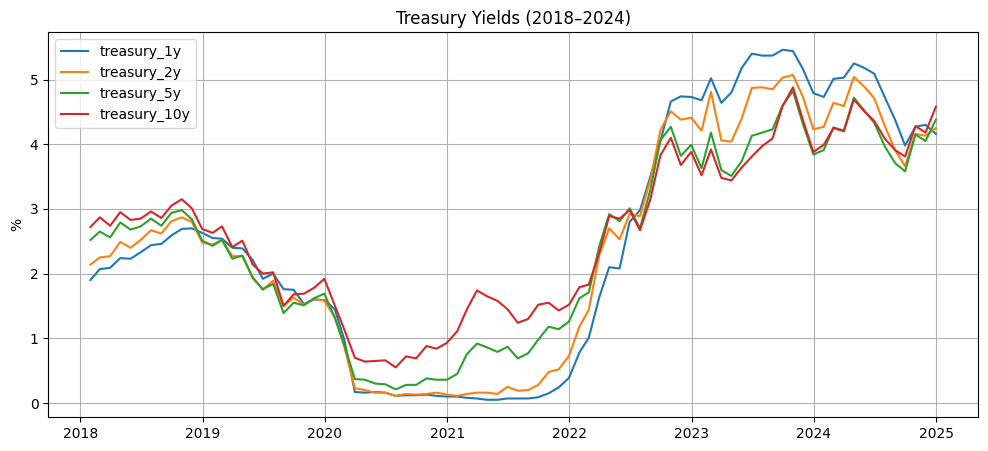

In [5]:
yield_cols = [c for c in data.columns if "treasury" in c]

plt.figure(figsize=(12,5))
for col in yield_cols:
    plt.plot(data.index, data[col], label=col)

plt.title("Treasury Yields (2018–2024)")
plt.ylabel("%")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
train = data.loc[:"2022-12-31"]
test  = data.loc["2023-01-01":]

yield_cols = [c for c in data.columns if "treasury" in c]

X_train = train.drop(columns=yield_cols)
X_test  = test.drop(columns=yield_cols)

y_train = train[yield_cols]
y_test  = test[yield_cols]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60, 8)
y_train: (60, 4)
X_test: (24, 8)
y_test: (24, 4)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
mean_pred = np.tile(y_train.mean().values, (len(y_test), 1))

baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
baseline_rmse

np.float64(2.7166743264206943)

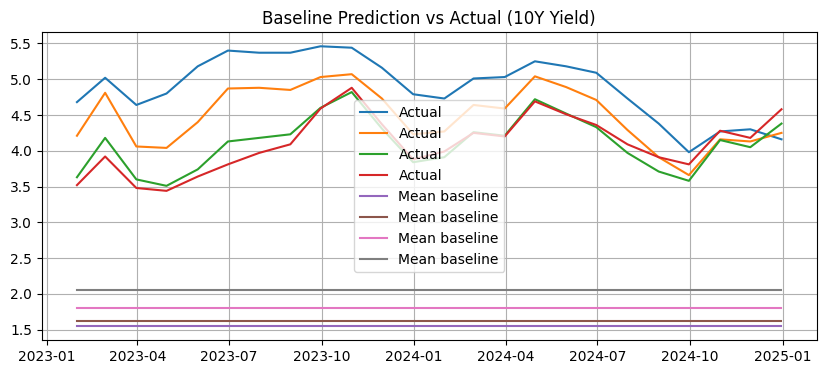

In [9]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, mean_pred, label="Mean baseline")
plt.title("Baseline Prediction vs Actual (10Y Yield)")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# intercept
Xb = np.column_stack([np.ones(X_train_scaled.shape[0]), X_train_scaled])
Xt = np.column_stack([np.ones(X_test_scaled.shape[0]), X_test_scaled])

beta = np.linalg.pinv(Xb.T @ Xb) @ (Xb.T @ y_train.values)

beta[:5]

array([[ 1.54783333,  1.62133333,  1.80383333,  2.0515    ],
       [ 2.18295455,  2.7307849 ,  2.36882637,  1.53544376],
       [ 0.3208178 ,  0.31060343,  0.13372529,  0.06300377],
       [-1.497647  , -1.85610856, -1.81959712, -1.44185073],
       [ 0.71159639,  0.92550592,  0.89655285,  0.74211763]])

In [11]:
lr_pred = Xt @ beta
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_rmse

np.float64(0.6546923674654097)

In [12]:
lr_pred = Xt @ beta
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_rmse

np.float64(0.6546923674654097)

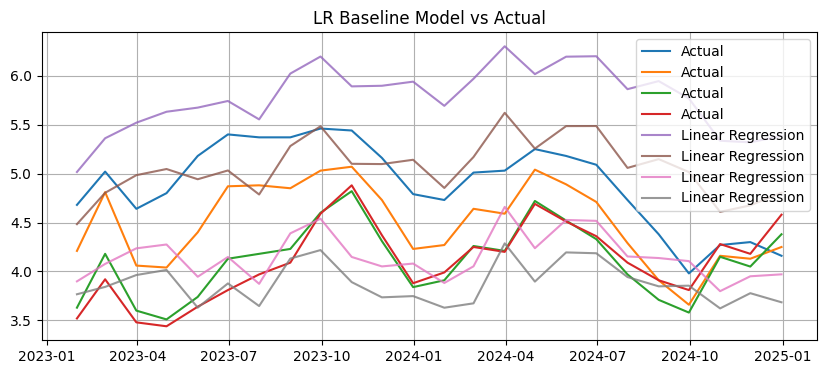

In [13]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, lr_pred, label="Linear Regression", alpha=0.8)
plt.title("LR Baseline Model vs Actual")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
class SimpleNN:
    def __init__(self, input_dim, hidden_dim=16, lr=0.001, output_dim=None):
        if output_dim is None:
            raise ValueError("output_dim must be provided")

        self.W1 = np.random.randn(input_dim, hidden_dim) / np.sqrt(input_dim)
        self.b1 = np.zeros(hidden_dim)

        self.W2 = np.random.randn(hidden_dim, output_dim) / np.sqrt(hidden_dim)
        self.b2 = np.zeros(output_dim)

        self.lr = lr

    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return (x > 0).astype(float)

    def train(self, X, y, epochs=200):
        for e in range(epochs):
            z1 = X @ self.W1 + self.b1
            a1 = self.relu(z1)
            z2 = a1 @ self.W2 + self.b2
            pred = z2

            loss = np.mean((pred - y)**2)

            dloss = 2 * (pred - y) / len(y)

            dW2 = a1.T @ dloss
            db2 = dloss.sum(axis=0)

            da1 = dloss @ self.W2.T
            dz1 = da1 * self.relu_deriv(z1)

            dW1 = X.T @ dz1
            db1 = dz1.sum(axis=0)

            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

    def predict(self, X):
        return self.relu(X @ self.W1 + self.b1) @ self.W2 + self.b2

In [15]:
nn = SimpleNN(
    input_dim=X_train_scaled.shape[1],
    hidden_dim=16,
    lr=0.001,
    output_dim=len(yield_cols)
)

In [16]:
nn_pred = nn.predict(X_test_scaled)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
nn_rmse

np.float64(3.69316757950193)

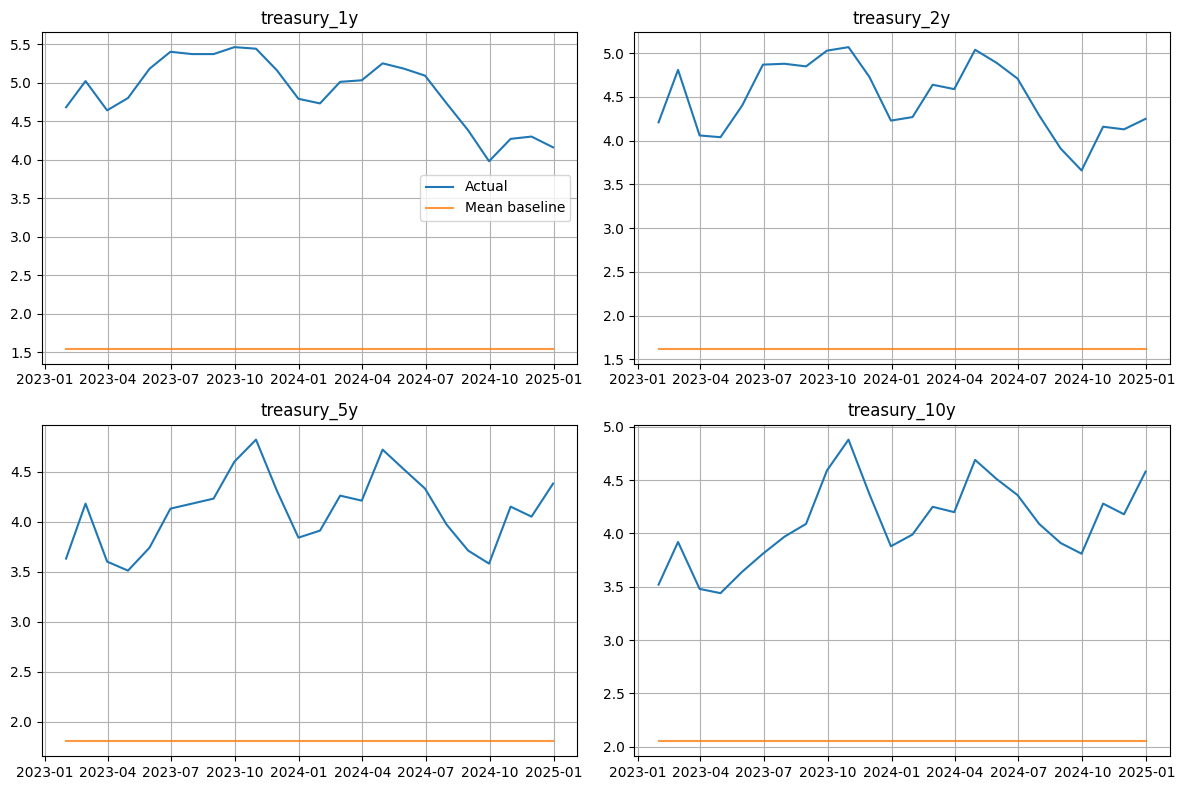

In [17]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(yield_cols):
    plt.subplot(2, 2, i+1)
    plt.plot(y_test.index, y_test[col], label="Actual")
    plt.plot(y_test.index, mean_pred[:, i], label="Mean baseline", alpha=0.8)
    plt.title(col)
    plt.grid(True)
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()

In [18]:
print("BASELINE RMSEs (2018-2024 test period)")
print("--------------------------------------")
print(f"Mean baseline:         {baseline_rmse:.4f}")
print(f"Linear Regression:     {lr_rmse:.4f}")
print(f"Manual Neural Network: {nn_rmse:.4f}")


BASELINE RMSEs (2018-2024 test period)
--------------------------------------
Mean baseline:         2.7167
Linear Regression:     0.6547
Manual Neural Network: 3.6932


In [19]:
nn_pred_df = pd.DataFrame(
    nn_pred,
    index=y_test.index,
    columns=[col + "_pred" for col in yield_cols]
)

nn_pred_df.to_csv("../data/nn_predictions_multi_output_2018_2024.csv")